# 1.0 Introdução

Texto de introdução aqui

 Descreva seu problema, seus dados, suas variáveis e a natureza de cada uma.

## Preparação dos Dados e Instalação das Bibliotecas

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid") # Configurando o estilo dos gráficos

df = pd.read_csv('C:\\estatisticacomp\\projeto de estatistica\\dataSets\\nordeste.csv') #Lendo o arquivo .csv

# Renomeando as colunas originais para facilitar a manipulação no código
df.rename(columns={
    'Unidade Territorial': 'Estado',
    'Referência': 'Periodo',
    'Número total de agricultores familiares fornecedores do PAA, todas as modalidades': 'Agricultores',
    'Valores pagos aos agricultores familiares fornecedores do PAA, todas as modalidades': 'Valores'
}, inplace=True)


# Limpeza e conversão de tipos
# A coluna de 'Valores' vem com vírgula (padrão brasileiro), precisamos trocar por ponto e converter para número (float)
df['Valores'] = df['Valores'].astype(str).str.replace(',', '.').astype(float)

## 1.1 SEÇÃO ANÁLISE UNIVARIADA: DISTRIBUIÇÕES DE FREQUÊNCIA

In [44]:
# A) Variável Qualitativa: Estado
freq_abs_estado = df['Estado'].value_counts()
freq_rel_estado = df['Estado'].value_counts(normalize=True) * 100

tabela_estado = pd.DataFrame({
    'Freq. Absoluta': freq_abs_estado, 
    'Freq. Relativa (%)': freq_rel_estado.round(2)
})

# Usando display e Markdown no lugar do print
display(Markdown("### Variável Qualitativa Nominal (Estado)"))
display(tabela_estado)

# B) Variável Quantitativa Contínua: Valores Pagos (Agrupada em 5 faixas)
faixas_valores = pd.cut(df['Valores'], bins=5)
freq_abs_valores = faixas_valores.value_counts().sort_index()
freq_rel_valores = faixas_valores.value_counts(normalize=True).sort_index() * 100

tabela_valores = pd.DataFrame({
    'Freq. Absoluta': freq_abs_valores, 
    'Freq. Relativa (%)': freq_rel_valores.round(2)
})

# Usando display e Markdown no lugar do print
display(Markdown("### Variável Quantitativa Contínua (Valores Pagos - Agrupados)"))
display(tabela_valores)

### Variável Qualitativa Nominal (Estado)

,Freq. Absoluta,Freq. Relativa (%)
Estado,,
MARANHÃO,16,11.11
PIAUÍ,16,11.11
CEARÁ,16,11.11
RIO GRANDE DO NORTE,16,11.11
PARAÍBA,16,11.11
PERNAMBUCO,16,11.11
ALAGOAS,16,11.11
SERGIPE,16,11.11
BAHIA,16,11.11


### Variável Quantitativa Contínua (Valores Pagos - Agrupados)

,Freq. Absoluta,Freq. Relativa (%)
Valores,,
"(-78926.443, 17550068.548]",61,42.36
"(17550068.548, 35091357.096]",52,36.11
"(35091357.096, 52632645.644]",25,17.36
"(52632645.644, 70173934.192]",5,3.47
"(70173934.192, 87715222.74]",1,0.69


## 1.2 SEÇÃO GRÁFICOS UNIVARIADOS

### 1. Gráfico de Variável Qualitativa Nominal
O gráfico abaixo ilustra a frequência de ocorrências divididas por **Estado** (Unidade Territorial). As barras foram ordenadas da maior para a menor frequência para facilitar a comparação visual.

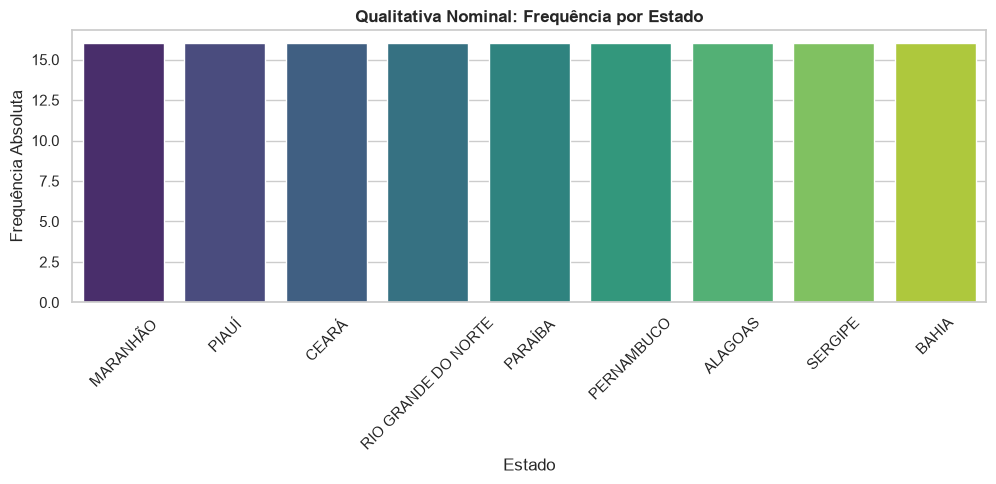

### 2. Gráfico de Variável Qualitativa Ordinal
Aqui observamos a distribuição dos registros ao longo do tempo. O eixo horizontal segue rigorosamente a **ordem cronológica** (Mês/Ano), respeitando a natureza ordinal desta variável.

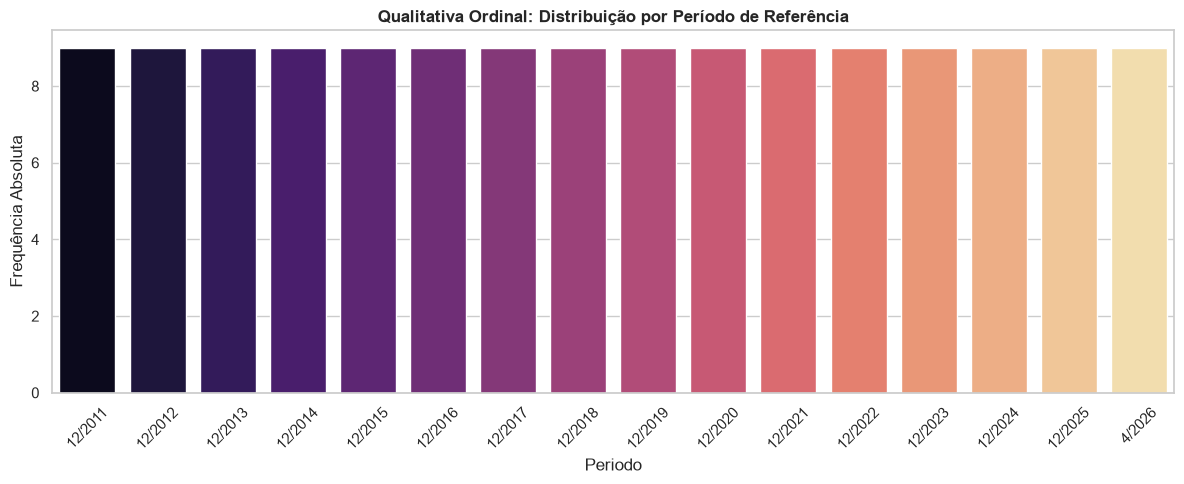

### 3. Gráfico de Variável Quantitativa Discreta
Este histograma demonstra a distribuição do **número de agricultores familiares**. Como se trata de contagem de pessoas (valores inteiros isolados), os dados foram agrupados em intervalos (bins) para evidenciar onde há maior concentração.

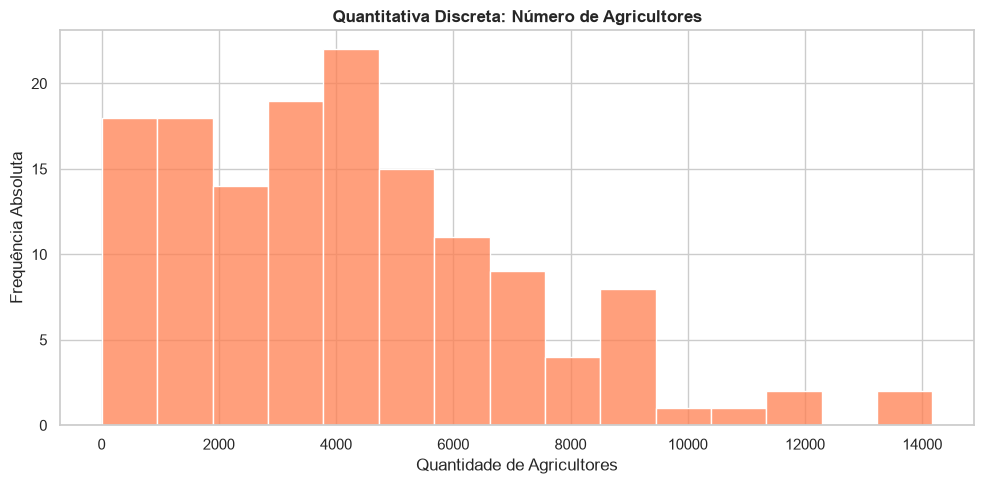

### 4. Gráfico de Variável Quantitativa Contínua
O gráfico apresenta a distribuição dos **valores financeiros pagos**. A linha contínua sobreposta representa a estimativa de densidade (KDE), ideal para entender a assimetria e a curva de dados contínuos.

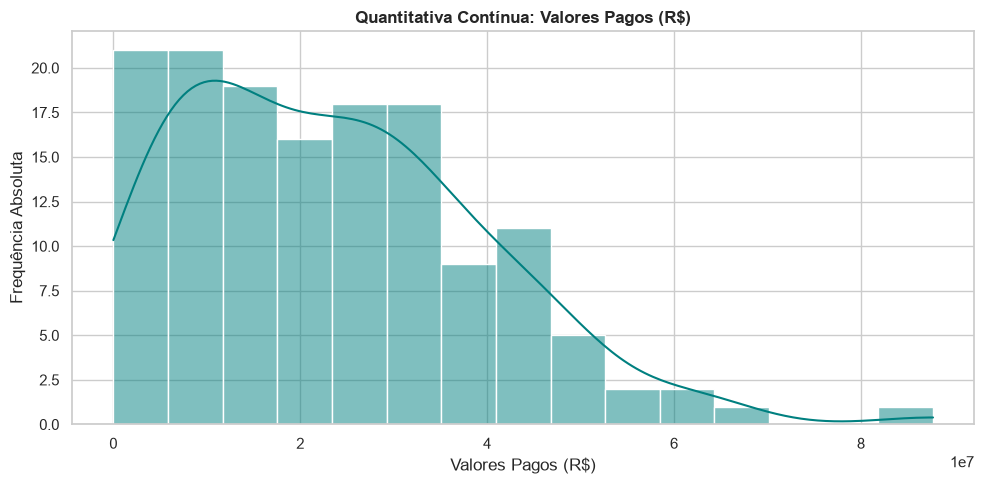

In [45]:
# 1. Qualitativa Nominal: Estado (Gráfico de Barras)
display(Markdown("### 1. Gráfico de Variável Qualitativa Nominal\nO gráfico abaixo ilustra a frequência de ocorrências divididas por **Estado** (Unidade Territorial). As barras foram ordenadas da maior para a menor frequência para facilitar a comparação visual."))

plt.figure(figsize=(10, 5))
# CORREÇÃO: Adicionado hue='Estado' e legend=False
sns.countplot(data=df, x='Estado', hue='Estado', order=df['Estado'].value_counts().index, palette='viridis', legend=False)
plt.title('Qualitativa Nominal: Frequência por Estado', fontweight='bold')
plt.ylabel('Frequência Absoluta')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Qualitativa Ordinal: Periodo (Gráfico de Barras)
display(Markdown("### 2. Gráfico de Variável Qualitativa Ordinal\nAqui observamos a distribuição dos registros ao longo do tempo. O eixo horizontal segue rigorosamente a **ordem cronológica** (Mês/Ano), respeitando a natureza ordinal desta variável."))

ordem_periodo = sorted(df['Periodo'].unique(), key=lambda x: pd.to_datetime(x, format='%m/%Y'))

plt.figure(figsize=(12, 5))
# CORREÇÃO: Adicionado hue='Periodo' e legend=False
sns.countplot(data=df, x='Periodo', hue='Periodo', order=ordem_periodo, palette='magma', legend=False)
plt.title('Qualitativa Ordinal: Distribuição por Período de Referência', fontweight='bold')
plt.ylabel('Frequência Absoluta')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3. Quantitativa Discreta: Agricultores (Histograma)
display(Markdown("### 3. Gráfico de Variável Quantitativa Discreta\nEste histograma demonstra a distribuição do **número de agricultores familiares**. Como se trata de contagem de pessoas (valores inteiros isolados), os dados foram agrupados em intervalos (bins) para evidenciar onde há maior concentração."))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Agricultores', bins=15, color='coral')
plt.title('Quantitativa Discreta: Número de Agricultores', fontweight='bold')
plt.ylabel('Frequência Absoluta')
plt.xlabel('Quantidade de Agricultores')
plt.tight_layout()
plt.show()


# 4. Quantitativa Contínua: Valores Pagos (Histograma com Curva KDE)
display(Markdown("### 4. Gráfico de Variável Quantitativa Contínua\nO gráfico apresenta a distribuição dos **valores financeiros pagos**. A linha contínua sobreposta representa a estimativa de densidade (KDE), ideal para entender a assimetria e a curva de dados contínuos."))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Valores', bins=15, kde=True, color='teal')
plt.title('Quantitativa Contínua: Valores Pagos (R$)', fontweight='bold')
plt.ylabel('Frequência Absoluta')
plt.xlabel('Valores Pagos (R$)')
plt.tight_layout()
plt.show()

## 1.3 SEÇÃO ANÁLISE BIVARIADA
Nesta seção, exploramos o comportamento e a relação entre duas variáveis simultaneamente.

### 1.3.1 Distribuição de Frequências Bivariada
A tabela de contingência abaixo cruza a variável qualitativa nominal (**Estado**) com a variável quantitativa contínua (**Valores Pagos**). Para que a leitura seja possível, os valores foram agrupados em 3 faixas.

Valores,"(-78926.443, 29244260.913]","(29244260.913, 58479741.827]","(58479741.827, 87715222.74]"
Estado,,,
ALAGOAS,6,10,0
BAHIA,5,8,3
CEARÁ,7,9,0
MARANHÃO,12,4,0
PARAÍBA,12,4,0
PERNAMBUCO,7,8,1
PIAUÍ,15,1,0
RIO GRANDE DO NORTE,15,1,0
SERGIPE,16,0,0


### 1.3.2 Figuras Bivariadas

**A) Gráfico de Dispersão: Agricultores vs. Valores Pagos**
Este gráfico cruza duas variáveis numéricas para identificar correlações. Cada ponto representa um registro, e as cores indicam o estado correspondente.

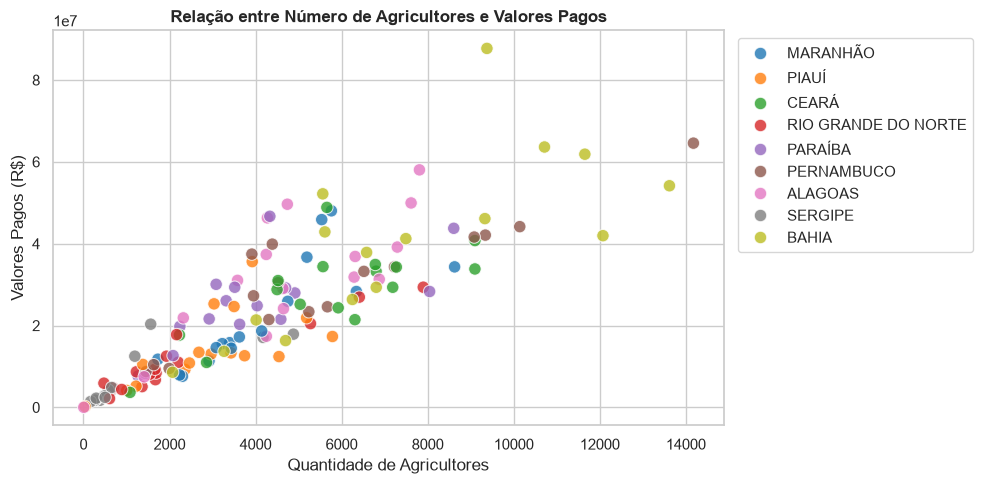

**B) Boxplot: Distribuição dos Valores Pagos por Estado**
O *boxplot* cruza categorias com números. Ele é ideal para comparar a mediana, a dispersão e identificar *outliers* (pontos atípicos que fogem do padrão) nos pagamentos de cada estado.

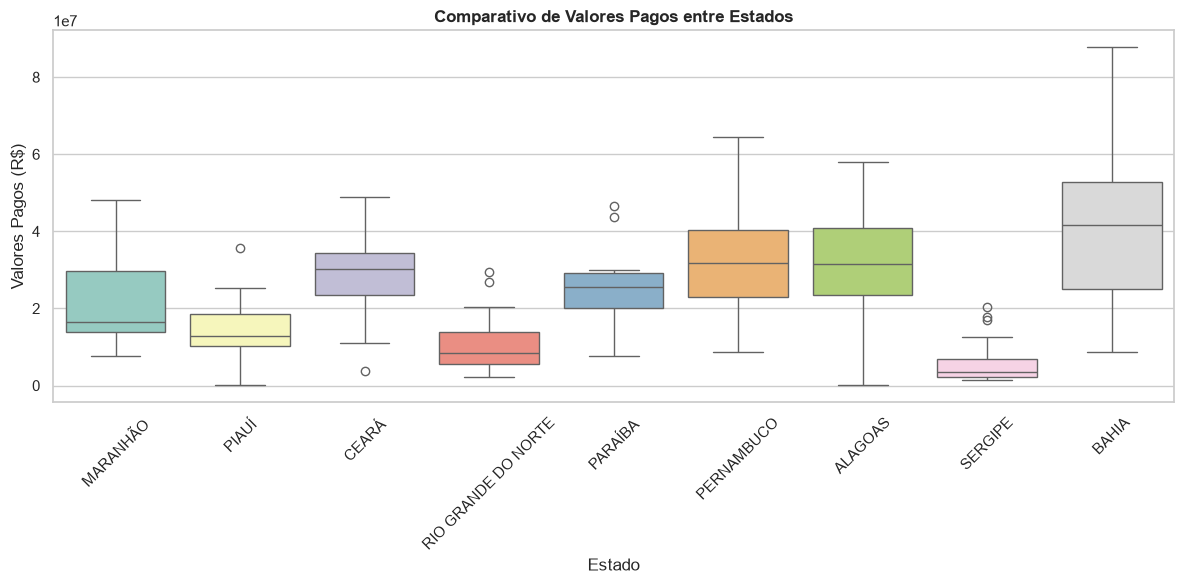

In [46]:
# ---------------------------------------------------------
# 1.3.1 Distribuição de Frequência Bivariada (Tabela Cruzada)
# ---------------------------------------------------------
display(Markdown("### 1.3.1 Distribuição de Frequências Bivariada\nA tabela de contingência abaixo cruza a variável qualitativa nominal (**Estado**) com a variável quantitativa contínua (**Valores Pagos**). Para que a leitura seja possível, os valores foram agrupados em 3 faixas."))

# Criando 3 faixas de valores numéricos para permitir o cruzamento tabular
faixas_bivariada = pd.cut(df['Valores'], bins=3)

# pd.crosstab gera a tabela de frequência bivariada
tabela_bivariada = pd.crosstab(df['Estado'], faixas_bivariada)

# Exibindo a tabela formatada
display(tabela_bivariada)


# ---------------------------------------------------------
# 1.3.2 Figuras Bivariadas
# ---------------------------------------------------------
display(Markdown("### 1.3.2 Figuras Bivariadas"))

# --- Figura A: Quantitativa vs Quantitativa (Dispersão) ---
display(Markdown("**A) Gráfico de Dispersão: Agricultores vs. Valores Pagos**\nEste gráfico cruza duas variáveis numéricas para identificar correlações. Cada ponto representa um registro, e as cores indicam o estado correspondente."))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Agricultores', y='Valores', hue='Estado', palette='tab10', s=80, alpha=0.8)
plt.title('Relação entre Número de Agricultores e Valores Pagos', fontweight='bold')
plt.ylabel('Valores Pagos (R$)')
plt.xlabel('Quantidade de Agricultores')
# Move a legenda para o lado de fora do gráfico para não cobrir os pontos
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') 
plt.tight_layout()
plt.show()


# --- Figura B: Qualitativa vs Quantitativa (Boxplot) ---
display(Markdown("**B) Boxplot: Distribuição dos Valores Pagos por Estado**\nO *boxplot* cruza categorias com números. Ele é ideal para comparar a mediana, a dispersão e identificar *outliers* (pontos atípicos que fogem do padrão) nos pagamentos de cada estado."))

plt.figure(figsize=(12, 6))
# Usando hue='Estado' e legend=False para evitar o aviso do Seaborn
sns.boxplot(data=df, x='Estado', y='Valores', hue='Estado', palette='Set3', legend=False)
plt.title('Comparativo de Valores Pagos entre Estados', fontweight='bold')
plt.ylabel('Valores Pagos (R$)')
plt.xlabel('Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  1.4 SEÇÃO MEDIDAS DE POSIÇÃO (TENDÊNCIA CENTRAL)
Estas medidas indicam em torno de qual valor os dados estão distribuídos. Foram calculadas a **Média** (ponto de equilíbrio), a **Mediana** (valor central que divide os dados ao meio) e a **Moda** (valor que mais se repete) para as nossas variáveis quantitativas."))

In [47]:
# Calculando as métricas para as variáveis numéricas
tendencia_central = pd.DataFrame({
    'Média': [df['Agricultores'].mean(), df['Valores'].mean()],
    'Mediana': [df['Agricultores'].median(), df['Valores'].median()],
    'Moda (1º valor)': [df['Agricultores'].mode()[0], df['Valores'].mode()[0]]
}, index=['Agricultores', 'Valores Pagos (R$)'])

tendencia_central = tendencia_central.round(2) # Arredondando os valores para 2 casas decimais para facilitar a leitura

display(tendencia_central) # Exibindo a tabela

,Média,Mediana,Moda (1º valor)
Agricultores,4236.17,3982.50,6.0
Valores Pagos (R$),23392280.20,21493929.29,8780.0


## 1.5 SEÇÃO MEDIDAS DE DISPERSÃO

In [48]:
display(Markdown("### As medidas de dispersão indicam o grau de variabilidade dos dados. Uma variação alta significa que os dados estão muito espalhados em relação à média.\n* **Amplitude:** Diferença entre o maior e o menor valor.\n* **Desvio Padrão:** O quanto, em média, os valores se afastam da média.\n* **Variância:** O desvio padrão ao quadrado (usado em cálculos estatísticos).\n* **Coeficiente de Variação (CV):** Medida relativa (em porcentagem) da dispersão. Valores acima de 30% geralmente indicam alta heterogeneidade dos dados."))

# Calculando Amplitude
amp_agricultores = df['Agricultores'].max() - df['Agricultores'].min()
amp_valores = df['Valores'].max() - df['Valores'].min()

# Calculando Coeficiente de Variação (CV = (Desvio Padrão / Média) * 100)
cv_agricultores = (df['Agricultores'].std() / df['Agricultores'].mean()) * 100
cv_valores = (df['Valores'].std() / df['Valores'].mean()) * 100

dispersao = pd.DataFrame({
    'Amplitude': [amp_agricultores, amp_valores],
    'Desvio Padrão': [df['Agricultores'].std(), df['Valores'].std()],
    'Variância': [df['Agricultores'].var(), df['Valores'].var()],
    'CV (%)': [cv_agricultores, cv_valores]
}, index=['Agricultores', 'Valores Pagos (R$)'])

# Arredondando
dispersao = dispersao.round(2)

# Exibindo a tabela
display(dispersao)

### As medidas de dispersão indicam o grau de variabilidade dos dados. Uma variação alta significa que os dados estão muito espalhados em relação à média.
* **Amplitude:** Diferença entre o maior e o menor valor.
* **Desvio Padrão:** O quanto, em média, os valores se afastam da média.
* **Variância:** O desvio padrão ao quadrado (usado em cálculos estatísticos).
* **Coeficiente de Variação (CV):** Medida relativa (em porcentagem) da dispersão. Valores acima de 30% geralmente indicam alta heterogeneidade dos dados.

,Amplitude,Desvio Padrão,Variância,CV (%)
Agricultores,14169.00,2937.28,8.627606e+06,69.34
Valores Pagos (R$),87706442.74,16244879.35,2.638961e+14,69.45
